# Diagnostic Analytics

The descriptive analysis identified several important business patterns, including differences in profitability across product categories and regions.

The purpose of diagnostic analytics is to investigate the underlying causes of these patterns by exploring relationships between variables and identifying the factors that influence business performance.

Rather than answering **what happened**, this notebook focuses on answering **why it happened**.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/feature_engineered_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Profit Margin,Customer Segment Type
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,0.1600,High
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,0.3000,High
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,0.4700,Low
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-0.4000,High
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,0.1125,Low


## Business Questions

The descriptive analysis identified several findings that require further investigation.

The following business questions will guide the diagnostic analysis:

1. Why does the Furniture category generate high sales but relatively low profit?

2. How does discounting affect profitability?

3. Why is the Central region less profitable than expected?

4. Which product sub-categories contribute most to business losses?

The answers to these questions will help explain the factors driving the business's overall performance.

## Investigation 1: Furniture Category Profitability

The descriptive analysis revealed that the Furniture category generated relatively high sales but considerably lower profit than the other product categories.

This investigation explores possible factors contributing to the low profitability of Furniture, including discounts, sub-categories, and regional performance.

In [4]:
category_discount = df.groupby('Category')['Discount'].mean()

category_discount

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

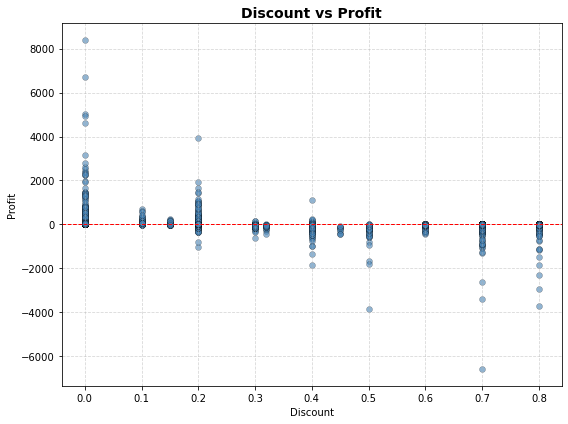

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.6,
    s=35,
    color='steelblue',
    edgecolors='black',
    linewidth=0.3
)

# Add a horizontal reference line
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.5)

plt.title('Discount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

### Findings: Average Discount by Category

The Furniture category recorded the highest average discount (17.39%), followed by Office Supplies (15.73%) and Technology (13.23%).

This finding suggests that Furniture products are discounted more heavily than products in the other categories. Higher discounting may be one of the factors contributing to Furniture's relatively low profitability.

However, this result alone does not prove that discounts cause lower profits. Further analysis is required to determine whether there is a relationship between discount levels and profitability.

In [6]:
df.groupby('Category')['Discount'].mean()

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

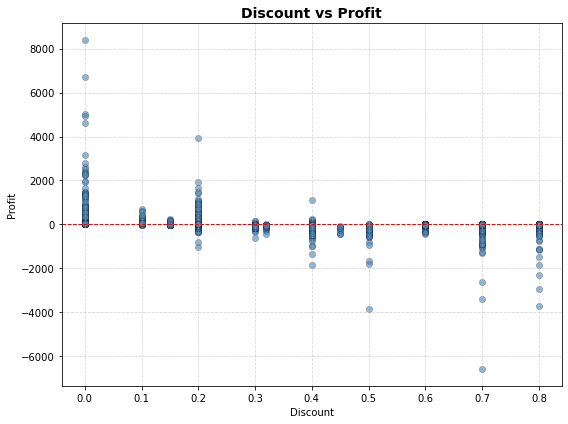

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    color='steelblue',
    alpha=0.6,
    s=40,
    edgecolors='black',
    linewidth=0.3
)

# Reference line at zero profit
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Gridlines
plt.grid(True, linestyle='--', alpha=0.5)

# Titles and labels
plt.title('Discount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

In [8]:
correlation = df['Discount'].corr(df['Profit'])

print(correlation)

-0.2194874563717678


### Findings: Relationship Between Discount and Profit

The correlation between discount and profit is **-0.2195**, indicating a weak negative relationship.

This suggests that, in general, higher discounts are associated with lower profits. However, the relationship is relatively weak, indicating that discounting alone does not fully explain variations in profitability.

The results support the hypothesis that discounts may contribute to lower profit, but additional factors such as product sub-categories, regional performance, and customer purchasing behaviour should also be investigated.

## Investigation 2: Furniture Sub-Category Performance

The previous analyses showed that the Furniture category generated relatively low profit and received the highest average discount.

This investigation examines the profitability of individual Furniture sub-categories to identify which products contribute most to the category's weak financial performance.

In [9]:
furniture = df[df['Category'] == 'Furniture']

furniture.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Profit Margin,Customer Segment Type
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,0.16,High
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,0.30,High
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-0.40,High
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,6,June,0.29,Medium
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2014,6,June,0.05,High


In [10]:
furniture_profit = (
    furniture.groupby('Sub-Category')['Profit']
             .sum()
             .sort_values()
)

furniture_profit

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Furnishings    13059.1436
Chairs         26590.1663
Name: Profit, dtype: float64

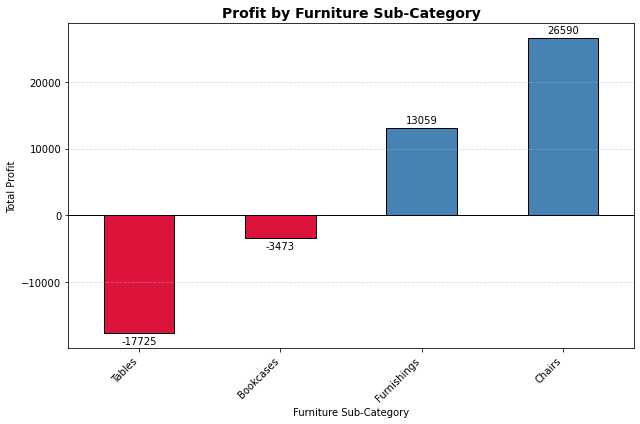

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

# Create the bar chart
ax = furniture_profit.plot(
    kind='bar',
    color=['crimson' if x < 0 else 'steelblue' for x in furniture_profit],
    edgecolor='black',
    linewidth=1
)

# Add a zero line
plt.axhline(y=0, color='black', linewidth=1)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

# Titles and labels
plt.title('Profit by Furniture Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Furniture Sub-Category')
plt.ylabel('Total Profit')

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Improve layout
plt.tight_layout()

plt.show()

In [13]:
furniture_profit

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Furnishings    13059.1436
Chairs         26590.1663
Name: Profit, dtype: float64

## Furniture Sub-Category Profitability

The analysis showed that profitability varies across the Furniture sub-categories.

Tables generated the largest loss (-17,725.48), making them the biggest contributor to the Furniture category's slow overall profit. Bookcases also recorded a negative profit (-3,472.56), although the loss was much smaller than that of Tables.

In contrast, Chairs generated the highest profit ($26,590.17), while Furnishings also remained profitable during the analysis period.

These findings suggest that the Furniture category's low profitability is mainly driven by losses in the Tables and Bookcases sub-categories rather than poor performance across all Furniture products. This insight enables the business to focus on improving the profitability of the specific product lines responsible for the losses.

## Investigation 3: Profitability by Category in the Central Region

The descriptive analysis showed that the Central region generated relatively low profit compared with its sales performance.

This investigation examines the profitability of each product category within the Central region to determine whether a particular category is contributing to the region's weaker financial performance.

In [14]:
central = df[df['Region'] == 'Central']

central_profit = (
    central.groupby('Category')['Profit']
           .sum()
           .sort_values()
)

central_profit

Category
Furniture          -2871.0494
Office Supplies     8879.9799
Technology         33697.4320
Name: Profit, dtype: float64

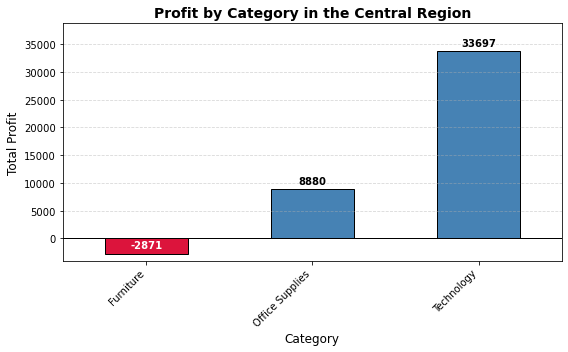

In [30]:
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(8, 5))

# Plot the bar chart
ax = central_profit.plot(
    kind='bar',
    color=['crimson' if x < 0 else 'steelblue' for x in central_profit],
    edgecolor='black',
    linewidth=1
)

# Zero reference line
plt.axhline(y=0, color='black', linewidth=1)

# Horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add space above and below the bars
ax.set_ylim(
    central_profit.min() * 1.4,
    central_profit.max() * 1.15
)

# Add value labels
for bar in ax.patches:
    height = bar.get_height()

    if height >= 0:
        # Positive bars
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 500,
            f'{height:.0f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    else:
        # Negative bars (centered inside the bar)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height * 0.4,
            f'{height:.0f}',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

# Titles and labels
plt.title('Profit by Category in the Central Region', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

## Findings: Profitability by Category in the Central Region

The analysis showed that the Furniture category was the only category to generate a loss in the Central region, recording a total profit of -$2,871.05.

In contrast, Technology generated the highest profit ($33,697.43), 

while Office Supplies also remained profitable with a total profit of $8,879.98.

These findings suggest that the Central region's relatively weak financial performance is largely influenced by losses in the Furniture category. This reinforces the earlier finding that Furniture is the weakest-performing product category and indicates that improvement efforts in the Central region should prioritise Furniture products.

In [16]:
central_furniture = df[
    (df['Region'] == 'Central') &
    (df['Category'] == 'Furniture')
]

central_furniture_profit = (
    central_furniture.groupby('Sub-Category')['Profit']
                     .sum()
                     .sort_values()
)

central_furniture_profit

Sub-Category
Furnishings   -3906.2168
Tables        -3559.6504
Bookcases     -1997.9043
Chairs         6592.7221
Name: Profit, dtype: float64

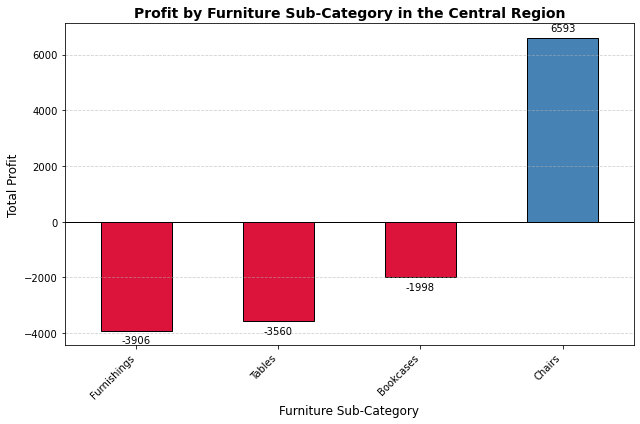

In [21]:
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(9, 6))

# Plot the bar chart
ax = central_furniture_profit.plot(
    kind='bar',
    color=['crimson' if x < 0 else 'steelblue' for x in central_furniture_profit],
    edgecolor='black',
    linewidth=1
)

# Add a horizontal line at zero
plt.axhline(y=0, color='black', linewidth=1)

# Add horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Title and axis labels
plt.title('Profit by Furniture Sub-Category in the Central Region', fontsize=14, fontweight='bold')
plt.xlabel('Furniture Sub-Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5, fontsize=10)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

In [22]:
central_furniture_profit

Sub-Category
Furnishings   -3906.2168
Tables        -3559.6504
Bookcases     -1997.9043
Chairs         6592.7221
Name: Profit, dtype: float64

## Findings: Furniture Sub-Category Profitability in the Central Region

The analysis revealed that profitability differs across the Furniture sub-categories within the Central region.

Furnishings recorded the largest loss (-$3,906.22), followed by Tables (-$3,559.65) and Bookcases (-$1,997.90).

Chairs remained profitable, generating a total profit of $6,592.72.

Unlike the overall business, where Tables generated the largest loss, the Central region experienced its greatest losses in Furnishings. This suggests that profitability challenges vary across regions and that regional factors may influence the performance of individual product lines.

These findings indicate that improving the profitability of Furniture in the Central region may require targeted strategies for specific sub-categories rather than applying a single solution across the entire Furniture category.

## Findings: Furniture Sub-Category Profitability in the Central Region

The analysis revealed that profitability differs across the Furniture sub-categories within the Central region.

Furnishings recorded the largest loss (-$3,906.22), 

followed by Tables (-$3,559.65) 

and Bookcases (-$1,997.90). 

Chairs remained profitable, generating a total profit of $6,592.72.

Unlike the overall business, where Tables generated the largest loss, the Central region experienced its greatest losses in Furnishings. This suggests that profitability challenges vary across regions and that regional factors may influence the performance of individual product lines.

These findings indicate that improving the profitability of Furniture in the Central region may require targeted strategies for specific sub-categories rather than applying a single solution across the entire Furniture category.